frame_0000.png | Potholes:1
frame_0001.png | Potholes:0
frame_0002.png | Potholes:0
frame_0003.png | Potholes:0
frame_0004.png | Potholes:1
frame_0005.png | Potholes:0
frame_0006.png | Potholes:0
frame_0007.png | Potholes:0
frame_0008.png | Potholes:0
frame_0009.png | Potholes:1
frame_0010.png | Potholes:1
frame_0011.png | Potholes:0
frame_0012.png | Potholes:0
frame_0013.png | Potholes:1
frame_0014.png | Potholes:0
frame_0015.png | Potholes:0
frame_0016.png | Potholes:0
frame_0017.png | Potholes:1
frame_0018.png | Potholes:0
frame_0019.png | Potholes:0
frame_0020.png | Potholes:0
frame_0021.png | Potholes:0
frame_0022.png | Potholes:0
frame_0023.png | Potholes:0
frame_0024.png | Potholes:0
frame_0025.png | Potholes:0
frame_0026.png | Potholes:1
frame_0027.png | Potholes:0
frame_0028.png | Potholes:0
frame_0029.png | Potholes:0
frame_0030.png | Potholes:0
frame_0031.png | Potholes:0
frame_0032.png | Potholes:0
frame_0033.png | Potholes:0
frame_0034.png | Potholes:0

Total frames: 35
To

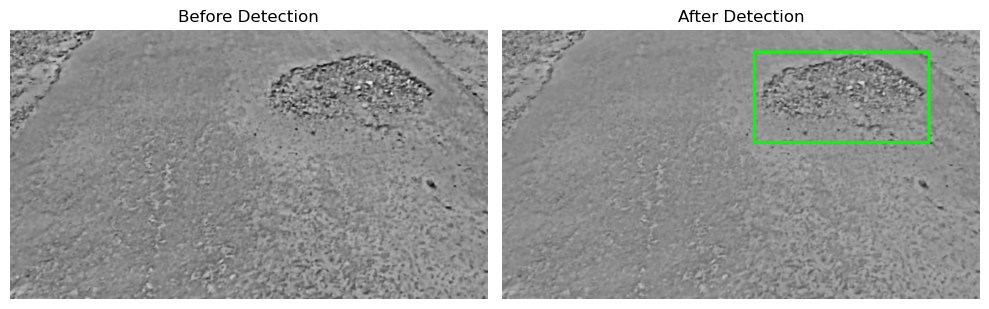

In [2]:
import cv2, os, numpy as np, matplotlib.pyplot as plt

inp = "final_output"
out = "marked_potholes"
os.makedirs(out, exist_ok=True)

total = 0
sample_before = None
sample_after = None

for f in sorted(os.listdir(inp)):

    img = cv2.imread(os.path.join(inp,f),0)
    if img is None:
        continue

    blur = cv2.GaussianBlur(img,(5,5),0)
    edges = cv2.Canny(blur,50,150)

    k = cv2.getStructuringElement(cv2.MORPH_RECT,(7,7))
    mask = cv2.dilate(edges,k,2)

    cnt,_ = cv2.findContours(mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

    marked = cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)
    potholes = 0

    for c in cnt:

        area = cv2.contourArea(c)
        x,y,w,h = cv2.boundingRect(c)

        if 5000 < area < 40000 and x > 40 and x+w < img.shape[1]-40:
            cv2.rectangle(marked,(x,y),(x+w,y+h),(0,255,0),3)
            potholes += 1

    total += potholes
    print(f"{f} | Potholes:{potholes}")

    # Save frame
    cv2.imwrite(os.path.join(out,f),marked)

    # Save one example for display
    if potholes > 0 and sample_before is None:
        sample_before = img
        sample_after = marked

print("\nTotal frames:",len(os.listdir(inp)))
print("Total potholes:",total)

# Show BEFORE vs AFTER example
if sample_before is not None:

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(sample_before,cmap="gray")
    plt.title("Before Detection")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(sample_after,cv2.COLOR_BGR2RGB))
    plt.title("After Detection")
    plt.axis("off")

    plt.tight_layout()
    plt.show()